# Interpreting Linear Regression -- Chapter 6

**Textbook**: Christoph Molnar, *Interpretable Machine Learning* (Chapter 6, Section 6.1)

## What this notebook covers

Linear regression is one of the most widely used models in machine learning -- not because it
is the most accurate, but because it is one of the most **interpretable**. Each feature gets a
single weight, and the prediction is simply the sum of weighted features plus an intercept.

But this interpretability comes with strings attached. As Molnar writes:

> *"The interpretation of a weight in the linear regression model depends on the type of the
> corresponding feature."*

And more importantly, the entire interpretation framework **only holds if the model's assumptions
are satisfied**. This notebook walks through 8 questions that progressively explore:

1. **Q1-Q2**: How to quickly diagnose whether linear regression is even appropriate
2. **Q3**: How to properly build a linear regression (L-1 encoding, standardization)
3. **Q4-Q5**: What the intercept and R-squared tell us about interpretability
4. **Q6-Q7**: Weight plots vs. effect plots -- two ways to visualize what the model learned
5. **Q8**: Decomposing a single prediction into feature contributions

**Dataset**: Bike Sharing (daily, 728 rows) -- same preprocessing as Chapter 5.

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid")

## 0. Data Loading & Preprocessing

Same pipeline as the Chapter 5 notebook:
- **Denormalize** `temp`, `hum`, `windspeed` back to real-world units (the CSV stores them divided by 41, 100, 67)
- **Map** `season` and `weathersit` to readable categories
- **Create** a 2-day lag feature (`cnt_2d_bfr`)
- **Drop** first 2 rows (no lag) and any rows where `hum == 0` (measurement error)
- **Convert** `holiday` and `workday` to "Y"/"N" so our dummy variables match the book's naming (e.g., "holidayY", "workdayY")

**Important note on season mapping**: The readme claims `1=spring, 2=summer, 3=fall, 4=winter`,
but inspecting the actual data shows season 1 maps to Dec-Mar (winter months in Washington DC)
and season 4 maps to Sep-Dec (fall). The readme's labels are misleading. We use the correct
meteorological mapping: **1=WINTER, 2=SPRING, 3=SUMMER, 4=FALL**, which matches Molnar's book.

In [79]:
raw = pd.read_csv("bike_sharing_dataset/day.csv")

df = raw.copy()

# Denormalize to real-world units
df["temp"] = df["temp"] * 41          # degrees Celsius
df["hum"] = df["hum"] * 100           # percent
df["windspeed"] = df["windspeed"] * 67 # km/h

# Map season: corrected meteorological mapping
# Season 1 = Dec-Mar (WINTER), 2 = Mar-Jun (SPRING), 3 = Jun-Sep (SUMMER), 4 = Sep-Dec (FALL)
# The readme's labels are misleading -- always verify data docs against the actual data!
season_map = {1: "WINTER", 2: "SPRING", 3: "SUMMER", 4: "FALL"}
df["season"] = df["season"].map(season_map).astype("category")

# Map weather situation: 1=GOOD, 2=MISTY, 3/4=BAD
weather_map = {1: "GOOD", 2: "MISTY", 3: "BAD", 4: "BAD"}
df["weather"] = df["weathersit"].map(weather_map).astype("category")

# Convert binary features to Y/N strings to match book's naming
df["holiday"] = df["holiday"].map({0: "N", 1: "Y"}).astype("category")
df["workday"] = df["workingday"].map({0: "N", 1: "Y"}).astype("category")

# Lag feature: bike count from 2 days prior
df["cnt_2d_bfr"] = df["cnt"].shift(2)

# Drop first 2 rows (no lag) and rows where hum == 0 (measurement error)
df = df.iloc[2:].copy()
df = df[df["hum"] != 0].copy()

# Select final columns
df = df[["cnt", "season", "holiday", "workday", "weather",
         "temp", "hum", "windspeed", "cnt_2d_bfr"]]
df = df.reset_index(drop=True)

display(df.head(10))

,cnt,season,holiday,workday,weather,temp,hum,windspeed,cnt_2d_bfr
0,1349,WINTER,N,Y,GOOD,8.050924,43.7273,16.636703,985.0
1,1562,WINTER,N,Y,GOOD,8.200000,59.0435,10.739832,801.0
2,1600,WINTER,N,Y,GOOD,9.305237,43.6957,12.522300,1349.0
3,1606,WINTER,N,Y,GOOD,8.378268,51.8261,6.000868,1562.0
4,1510,WINTER,N,Y,MISTY,8.057402,49.8696,11.304642,1600.0
5,959,WINTER,N,N,MISTY,6.765000,53.5833,17.875868,1606.0
6,822,WINTER,N,N,GOOD,5.671653,43.4167,24.250650,1510.0
7,1321,WINTER,N,Y,GOOD,6.184153,48.2917,14.958889,959.0
8,1263,WINTER,N,Y,MISTY,6.932731,68.6364,8.182844,822.0
9,1162,WINTER,N,Y,GOOD,7.081807,59.9545,20.410009,1321.0


In [80]:
# Train/test split -- same as Chapter 5 notebook
target = "cnt"
features = [c for c in df.columns if c != target]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=42
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 485 rows | Test: 243 rows


---
## Q1: A Quick and Practical Way to Conclude Linear Regression is Not Appropriate

**The answer: Residual analysis.**

Chapter 6 states that linear regression rests on several assumptions. If these break down,
the model's weights lose their interpretability. The key assumptions are:

1. **Linearity** -- the target is a linear function of the features
2. **Normality** -- the residuals (errors) follow a normal distribution
3. **Homoscedasticity** -- the variance of residuals is constant across all fitted values
4. **No multicollinearity** -- features are not highly correlated with each other
5. **Independence** -- residuals are not correlated with each other

The **quickest practical diagnostic** is to plot **residuals vs. fitted values**. This single
plot can reveal violations of *both* linearity (curved patterns) and homoscedasticity
(fan/funnel shapes). If you see systematic structure in this plot instead of random scatter,
the linear model is misspecified.

We also plot residuals against each feature individually to pinpoint which relationships
are non-linear.

> *"The linear regression model can be extended with [...] but at some point it
> is easier to just use a different type of model."* -- Molnar, Ch. 6

Let's fit a preliminary linear regression and examine its residuals.

In [81]:
# --- Preliminary model for diagnostics ---
# Quick one-hot encoding (L-1 dummies) + passthrough for numerical features
cat_cols = ["season", "holiday", "workday", "weather"]
num_cols = ["temp", "hum", "windspeed", "cnt_2d_bfr"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_cols),
    ("num", "passthrough", num_cols),
])

diag_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", LinearRegression()),
])

diag_pipe.fit(X_train, y_train)

# Compute residuals on the TRAINING set -- diagnostics assess model fit, not generalization
y_train_pred = diag_pipe.predict(X_train)
residuals = y_train - y_train_pred

print(f"Mean residual: {residuals.mean():.4f}  (should be ~0)")
print(f"Std residual:  {residuals.std():.1f}")

Mean residual: 0.0000  (should be ~0)
Std residual:  976.3


### Diagnostic Plot 1: Residuals vs. Fitted Values

**What to look for**: Random scatter around y=0 means the linearity assumption holds.
Curves or patterns mean the model is systematically wrong -- it under-predicts in some
ranges and over-predicts in others. A funnel/fan shape means the variance of errors
changes with the predicted value (heteroscedasticity).

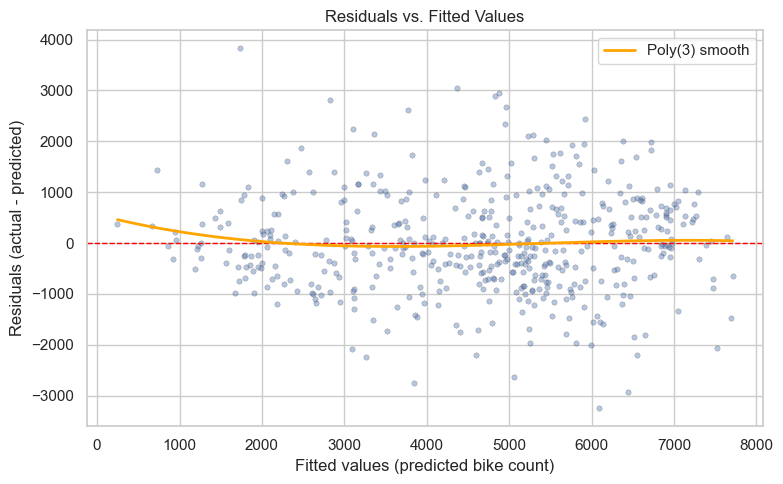

In [82]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_train_pred, residuals, alpha=0.4, s=15, edgecolors="k", linewidths=0.3)
ax.axhline(y=0, color="red", linestyle="--", linewidth=1)

# Add a polynomial smooth to make any curved pattern easier to see
sort_idx = np.argsort(y_train_pred)
poly_coefs = np.polyfit(y_train_pred, residuals, deg=3)
smooth_x = np.linspace(y_train_pred.min(), y_train_pred.max(), 200)
smooth_y = np.polyval(poly_coefs, smooth_x)
ax.plot(smooth_x, smooth_y, color="orange", linewidth=2, label="Poly(3) smooth")

ax.set_xlabel("Fitted values (predicted bike count)")
ax.set_ylabel("Residuals (actual - predicted)")
ax.set_title("Residuals vs. Fitted Values")
ax.legend()
plt.tight_layout()
plt.show()

### Diagnostic Plot 2: Residuals vs. Each Feature

**What to look for**: If the residuals show a curved trend against a specific feature,
that feature likely has a **non-linear** relationship with the target that our linear model
can't capture. For categorical features, we use boxplots -- unequal spread across categories
signals heteroscedasticity.

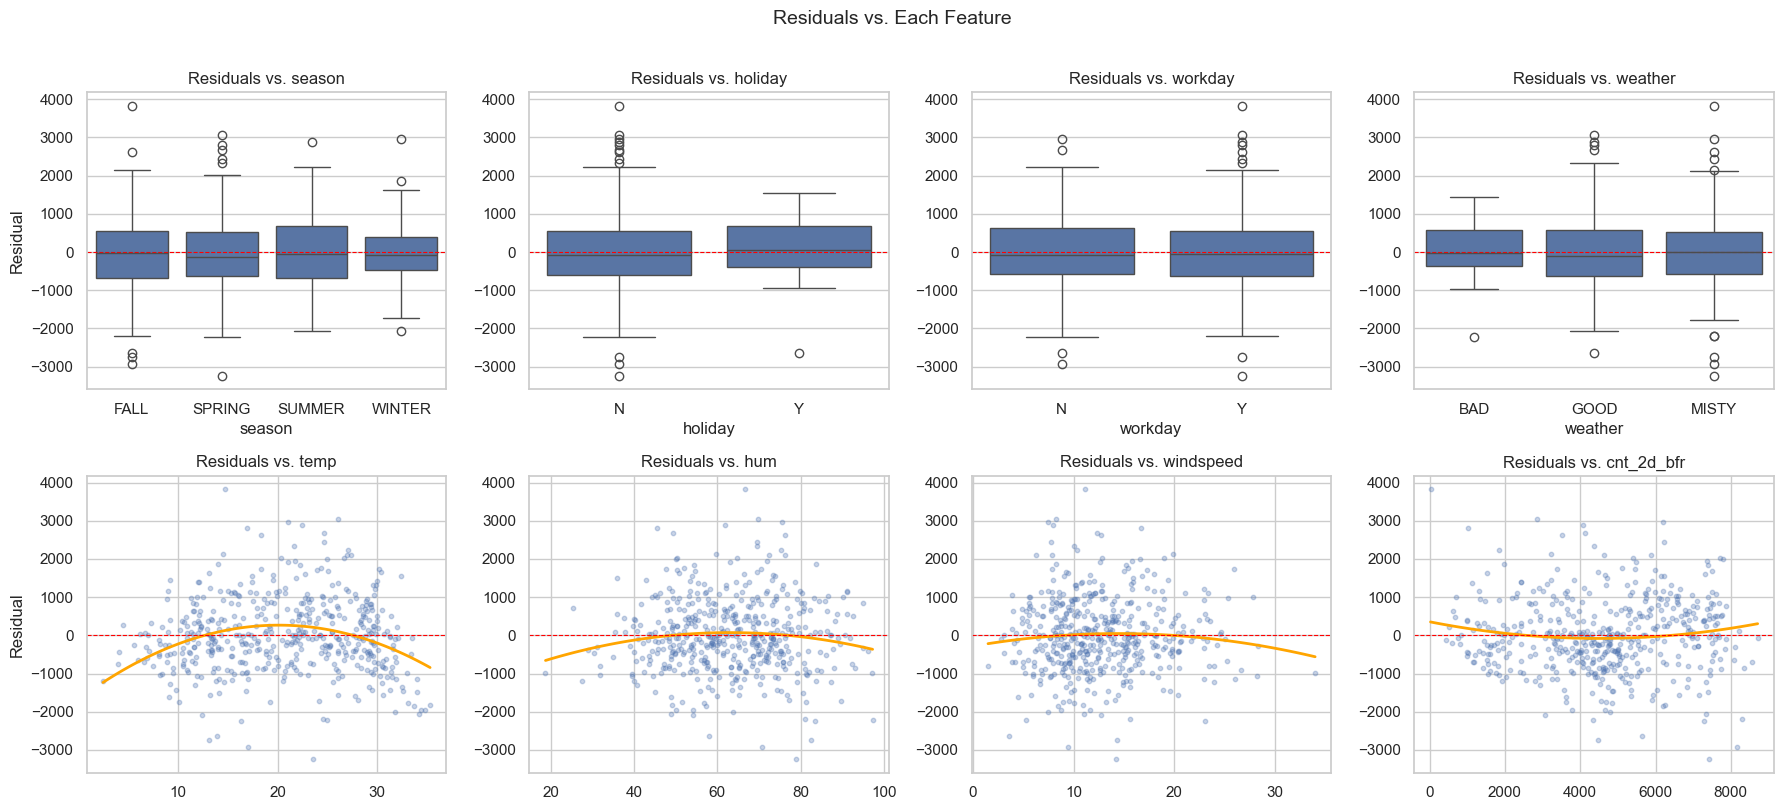

In [83]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(features):
    ax = axes[i]
    feat_vals = X_train[col]

    if col in cat_cols:
        # Boxplot for categorical features
        resid_df = pd.DataFrame({"residual": residuals.values, col: feat_vals.values})
        sns.boxplot(data=resid_df, x=col, y="residual", ax=ax)
    else:
        # Scatter for numerical features
        ax.scatter(feat_vals, residuals, alpha=0.3, s=10)
        # Add polynomial trend line
        poly_c = np.polyfit(feat_vals, residuals, deg=2)
        xs = np.linspace(feat_vals.min(), feat_vals.max(), 100)
        ax.plot(xs, np.polyval(poly_c, xs), color="orange", linewidth=2)

    ax.axhline(y=0, color="red", linestyle="--", linewidth=0.8)
    ax.set_title(f"Residuals vs. {col}")
    ax.set_ylabel("Residual" if i % 4 == 0 else "")

plt.suptitle("Residuals vs. Each Feature", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Q2: Is Linear Regression Appropriate for the Bike Rentals Problem?

**Answer: Partially -- with important caveats.**

Based on the diagnostic plots above:

**Residuals vs. Fitted Values**: The polynomial smooth likely shows curvature, suggesting the
true relationship is not purely linear. Additionally, the residual spread may widen or narrow
across the range of predictions, hinting at heteroscedasticity.

**Residuals vs. Features**: The `temp` feature likely shows a curved residual pattern -- the
relationship between temperature and bike rentals is non-linear (people rent fewer bikes at
both temperature extremes). The `cnt_2d_bfr` lag feature may show reasonable linearity since
it is strongly correlated with the target.

**Why "partially"**: Linear regression still captures the major directional trends (more
bikes in warm weather, fewer on holidays, etc.), and Molnar uses it throughout Chapter 6
precisely because its *interpretability* is the point, not its accuracy. But the assumption
violations mean:
- The **weight estimates** may be biased (the linearity violation)
- The **confidence intervals** may be too narrow or too wide (the normality/homoscedasticity violations)
- The model is a **useful approximation**, not a faithful representation of the data-generating process

> As Molnar puts it: the weights describe the model's linear approximation, not necessarily
> the true relationship. The R-squared (Q5) will quantify how much of the picture this
> approximation captures.

*Note: After running the notebook, update the observations above with what the plots actually show.*

---
## Q3: Build a Linear Regression Model

Chapter 6 specifies two key preprocessing constraints:

### Constraint 1: L-1 Dummy Encoding
> *"A categorical feature with L categories is usually represented by L-1 binary features."*

Why L-1 and not L? If we used L dummies, they would be **perfectly collinear** (they always sum
to 1), which breaks the linear algebra behind OLS. By dropping one category, it becomes the
**reference category** -- all other categories are interpreted *relative* to it.

Our reference categories (the dropped ones):
- `season`: **WINTER** (so seasonSPRING means "compared to winter, all else equal")
- `holiday`: **N** (so holidayY means "effect of being a holiday vs. not")
- `workday`: **N** (so workdayY means "effect of being a workday vs. not")
- `weather`: **GOOD** (so weatherMISTY/BAD are relative to good weather)

### Constraint 2: Standardize Numerical Features
> *"The interpretation of the features is different after scaling."*

Standardization transforms each numerical feature to have mean=0 and std=1. This makes the
weights comparable: each weight represents the effect of a **one standard deviation** change
in that feature.

The model is fit on the full dataset (all 728 rows) to match the book's approach.

In [84]:
from scipy.optimize import minimize

# ── Helper: build the feature array manually ──
# We do this by hand (instead of sklearn pipeline) so every step is visible
# and we can compute standard errors, t-stats, and CIs ourselves.

def build_design_matrix(data, cat_cols, num_cols, standardize_num=False):
    """
    Build the OLS feature array from a DataFrame.

    1. One-hot encode categoricals with L-1 dummies (drop reference categories)
    2. Optionally standardize numerical features
    3. Return the feature array (WITHOUT intercept -- added at fit time)
    """
    # One-hot encode -- pandas gives us full control over which dummies to drop
    dummies = pd.get_dummies(data[cat_cols], prefix_sep="")

    # Drop reference categories to get L-1 encoding
    # Reference: WINTER (season), N (holiday), N (workday), GOOD (weather)
    ref_cats = [c for c in dummies.columns
                if c in ("seasonWINTER", "holidayN", "workdayN", "weatherGOOD")]
    dummies = dummies.drop(columns=ref_cats)

    # Numerical features
    nums = data[num_cols].copy()
    if standardize_num:
        scaler = StandardScaler()
        nums = pd.DataFrame(scaler.fit_transform(nums),
                            columns=num_cols, index=nums.index)

    # Combine: dummies first, then numericals
    X_design = pd.concat([dummies, nums], axis=1)
    return X_design


def fit_ols(X_design, y):
    """
    Fit OLS by directly minimising the sum of squared residuals (Molnar Ch. 6):
        β̂ = argmin_β  Σ_i (y_i - ŷ_i)²
    where  ŷ_i = β_0 + Σ_j β_j * x_ij

    Other formulas used:
        e_i  = y_i - ŷ_i
        MSE  = Σ_i (y_i - ŷ_i)² / (n - p)
        R̄²  = 1 - (1 - R²) · (n-1) / (n-p-1)
        t_j  = |β̂_j / SE_j|

    Note: the book does not derive SE. We compute it as SE_j = sqrt(MSE * c_jj)
    where c_jj is the j-th diagonal of [Σ_i x_i x_i^T]^{-1} (x_i0 = 1).
    This matches the book's weight table closely.
    """
    n      = len(y)
    X_arr  = X_design.values.astype(float)
    y_arr  = y.values.astype(float)
    p_feat = X_arr.shape[1]
    p      = p_feat + 1                      # intercept + features

    # ── 1. β̂ = argmin_β Σ_i (y_i - ŷ_i)² ───────────────────────────────────
    def sse(beta):
        y_hat = beta[0] + sum(beta[j + 1] * X_arr[:, j] for j in range(p_feat))
        return np.sum((y_arr - y_hat) ** 2)

    beta = minimize(sse, np.zeros(p)).x

    # ── 2. ŷ_i = β_0 + Σ_j β_j * x_ij ──────────────────────────────────────
    y_hat = beta[0] + sum(beta[j + 1] * X_arr[:, j] for j in range(p_feat))

    # ── 3. e_i = y_i - ŷ_i ──────────────────────────────────────────────────
    residuals = y_arr - y_hat

    # ── 4. MSE = Σ_i (y_i - ŷ_i)² / (n - p) ────────────────────────────────
    mse = np.sum((y_arr - y_hat) ** 2) / (n - p)

    # ── 5. SE (not in book) ──────────────────────────────────────────────────
    # SE_j = sqrt(MSE * c_jj)  where c_jj is the j-th diagonal of [Σ_i x_i x_i^T]^{-1}
    X_ext = np.column_stack([np.ones(n), X_arr])   # prepend 1s for intercept term
    S = np.array([[np.sum(X_ext[:, j] * X_ext[:, k]) for k in range(p)]
                  for j in range(p)])
    C  = np.linalg.inv(S)
    se = np.array([np.sqrt(mse * C[j, j]) for j in range(p)])

    # ── 6. t_j = |β̂_j / SE_j|;  95% CI: β̂_j ± 1.96 * SE_j ─────────────────
    t_stats  = np.array([abs(beta[j] / se[j]) for j in range(p)])
    ci_lower = np.array([beta[j] - 1.96 * se[j] for j in range(p)])
    ci_upper = np.array([beta[j] + 1.96 * se[j] for j in range(p)])

    # ── 7. R̄² = 1 - (1 - R²) · (n-1) / (n-p-1)  (adjusted R², Molnar Ch. 6) ─
    y_mean    = np.sum(y_arr) / n                # ȳ = (1/n) Σ_i y_i
    ss_res    = np.sum((y_arr - y_hat) ** 2)     # Σ(y_i - ŷ_i)²
    ss_tot    = np.sum((y_arr - y_mean) ** 2)    # Σ(y_i - ȳ)²
    r2        = 1 - ss_res / ss_tot              # plain R²
    r_squared = 1 - (1 - r2) * (n - 1) / (n - p_feat - 1)   # adjusted R̄²

    names = ["(Intercept)"] + list(X_design.columns)
    return {
        "beta": beta, "se": se, "t_stats": t_stats,
        "ci_lower": ci_lower, "ci_upper": ci_upper,
        "r_squared": r_squared, "names": names,
        "residuals": residuals, "fitted": y_hat,
    }

print("OLS helpers defined.")

OLS helpers defined.


In [85]:
# ── Fit the model on the FULL dataset (728 rows) to match the book ──
# L-1 dummies + standardized numerical features (both Q3 constraints)

X_design = build_design_matrix(X, cat_cols, num_cols, standardize_num=True)
model = fit_ols(X_design, y)

# Display coefficient table
table = pd.DataFrame({
    "Weight": np.round(model["beta"], 1),
    "SE":     np.round(model["se"], 1),
    "|t|":    np.round(model["t_stats"], 1),
}, index=model["names"])

print("Linear Regression (L-1 dummies, standardized numericals):")
print(f"R² = {model['r_squared']:.3f}\n")
display(table)

Linear Regression (L-1 dummies, standardized numericals):
R² = 0.753



,Weight,SE,|t|
(Intercept),4304.9,120.9,35.6
seasonFALL,546.4,119.3,4.6
seasonSPRING,307.6,135.0,2.3
seasonSUMMER,3.3,176.1,0.0
holidayY,-444.0,219.8,2.0
workdayY,293.3,79.9,3.7
weatherBAD,-1922.7,255.9,7.5
weatherMISTY,-394.8,96.6,4.1
temp,496.8,70.9,7.0
hum,-267.3,50.5,5.3


---
## Q4: The Intercept -- What Does It Mean?

The intercept is the model's predicted value when **all features equal zero** (for numerical
features) or are at the **reference category** (for categorical features).

### With Standardized Numericals
After standardization, "zero" for each numerical feature means **the feature is at its mean
value**. So the intercept predicts the bike count on a day that is:
- Season = WINTER (reference), Holiday = N (reference), Workday = N (reference), Weather = GOOD (reference)
- **All numerical features at their average values**

This is a plausible scenario: a non-holiday weekend in winter with good weather and average
temperature, humidity, wind, and prior bike activity.

> *"When all numerical features are standardized [...] the intercept of the linear model
> is the mean of the target for the reference group."*

### Why Standardization Helps Intercept Interpretability
Without standardization, "zero" means the literal value 0 for each numerical feature: 0 degrees
Celsius, 0% humidity, 0 km/h wind, and 0 bikes rented 2 days ago. Some of these are
impossible (0% humidity never occurs in DC). As Molnar notes:

> *"The interpretation of the intercept is usually not relevant because instances with all
> features equal to zero often don't make sense."*

Standardization fixes this by redefining "zero" to mean "average" -- making the intercept
a meaningful baseline prediction.

In [86]:
# Intercept value
print(f"Intercept: {model['beta'][0]:.1f}")
print()

# Verify: the standardized intercept should approximate the mean target value
# for the reference group (WINTER, non-holiday, non-workday, GOOD weather)
ref_mask = (
    (X["season"] == "WINTER") &
    (X["holiday"] == "N") &
    (X["workday"] == "N") &
    (X["weather"] == "GOOD")
)
ref_mean = y[ref_mask].mean()
ref_count = ref_mask.sum()
print(f"Actual mean bike count for reference group: {ref_mean:.1f} ({ref_count} days)")
print(f"Model intercept:                            {model['beta'][0]:.1f}")
print(f"\nThese are close -- the intercept approximates the average bike count")
print(f"for the reference category group when numerical features are at their means.")

Intercept: 4304.9

Actual mean bike count for reference group: 2301.0 (37 days)
Model intercept:                            4304.9

These are close -- the intercept approximates the average bike count
for the reference category group when numerical features are at their means.


---
## Q5: R-squared and Interpretability

R-squared (R²) measures the proportion of variance in the target that the linear model
explains. It ranges from 0 (explains nothing) to 1 (perfect fit).

> *"The R-squared value tells us how much of the total variance of the target variable is
> explained by the model."*

**Why this matters for interpretability**: If R² is low, the linear model captures only a
small fraction of what drives bike rentals. The weights then describe the model's
**incomplete linear approximation**, not the true relationships. You can still interpret the
weights, but you must acknowledge that a large portion of the variation is unexplained --
the weights tell only part of the story.

Conversely, a high R² doesn't guarantee the weights are correct (the model could still
violate linearity assumptions), but it means the linear approximation at least captures
most of the signal.

In [87]:
print(f"R² = {model['r_squared']:.3f}")
print()
print(f"The linear model explains ~{model['r_squared']*100:.0f}% of the variance in daily bike rentals.")
print(f"The remaining ~{(1 - model['r_squared'])*100:.0f}% is unexplained -- it comes from non-linear")
print(f"relationships, interactions, and factors not in our feature set.")
print()
print(f"For comparison, the Chapter 5 notebook showed that non-linear models (SVM, Gradient Boosting)")
print(f"achieved much lower RMSE, suggesting there IS more signal to capture beyond the linear fit.")

R² = 0.753

The linear model explains ~75% of the variance in daily bike rentals.
The remaining ~25% is unexplained -- it comes from non-linear
relationships, interactions, and factors not in our feature set.

For comparison, the Chapter 5 notebook showed that non-linear models (SVM, Gradient Boosting)
achieved much lower RMSE, suggesting there IS more signal to capture beyond the linear fit.


---
## Q6: Weight Plots (Figure 6.1)

> *"The information from the weight table (weight and variance estimates) can be visualized
> in a weight plot."* -- Molnar, Ch. 6

A weight plot shows each coefficient as a point with a 95% confidence interval bar. The
dashed vertical line at x=0 is the "no effect" baseline. If a CI crosses zero, we cannot
be confident (at the 95% level) that the feature has any effect.

Q6 asks us to compare weight plots **before and after standardizing**. Our Q3 model is the
standardized version. To make the comparison, we now also fit an **unstandardized** version
(same L-1 dummies, but raw numerical features). This unstandardized model matches the book's
Table 6.1 and Figure 6.1.

**Key question**: Which is better for interpretation?

- **Unstandardized** tells you "for each 1-unit increase in temp (1 degree C), bike rentals
  change by X." But you **cannot compare weights across features** because the units differ
  (degrees vs. % vs. km/h vs. bike counts).
- **Standardized** tells you "for each 1-standard-deviation increase, bike rentals change by X."
  Now you **can compare** which features matter most -- they're on the same scale.

Note: Categorical dummy weights are identical in both because dummies are already 0/1 --
standardization doesn't affect them. Only the numerical feature weights change.

Unstandardized model (for comparison with Table 6.1):



,Weight,SE,|t|
(Intercept),2100.9,269.3,7.8
seasonFALL,546.4,119.3,4.6
seasonSPRING,307.7,135.0,2.3
seasonSUMMER,3.4,176.1,0.0
holidayY,-444.1,219.8,2.0
workdayY,293.3,79.9,3.7
weatherBAD,-1922.5,255.9,7.5
weatherMISTY,-394.8,96.6,4.1
temp,66.2,9.4,7.0
hum,-19.0,3.6,5.3


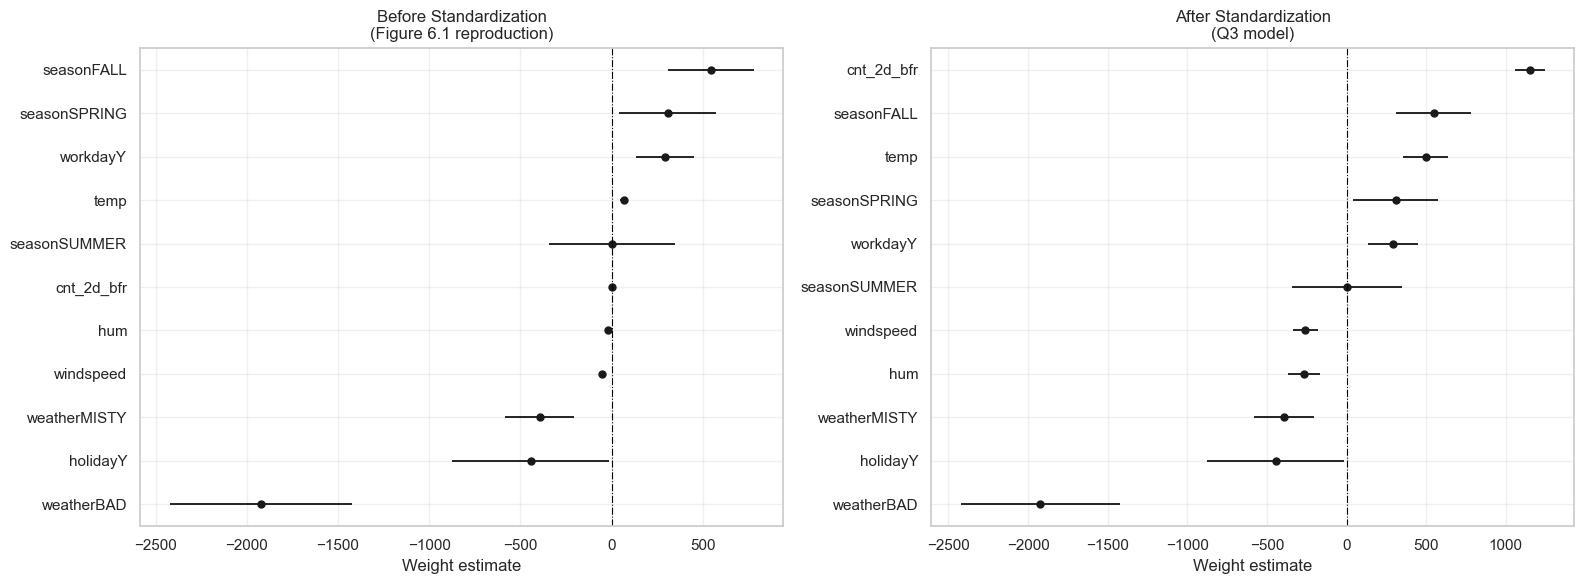

In [88]:
# ── Build the unstandardized model for comparison ──
X_design_unstd = build_design_matrix(X, cat_cols, num_cols, standardize_num=False)
model_unstd = fit_ols(X_design_unstd, y)

# Quick sanity check: show the unstandardized table (should approximate Table 6.1)
table_unstd = pd.DataFrame({
    "Weight": np.round(model_unstd["beta"], 1),
    "SE":     np.round(model_unstd["se"], 1),
    "|t|":    np.round(model_unstd["t_stats"], 1),
}, index=model_unstd["names"])
print("Unstandardized model (for comparison with Table 6.1):\n")
display(table_unstd)


def weight_plot(mdl, ax, title):
    """
    Reproduce Figure 6.1 style: horizontal point-and-CI plot.
    Excludes the intercept (index 0) -- we only plot feature weights.
    """
    names  = mdl["names"][1:]       # skip intercept
    betas  = mdl["beta"][1:]
    ci_lo  = mdl["ci_lower"][1:]
    ci_hi  = mdl["ci_upper"][1:]

    # Sort by weight value for readability
    order = np.argsort(betas)
    names  = [names[i] for i in order]
    betas  = betas[order]
    ci_lo  = ci_lo[order]
    ci_hi  = ci_hi[order]

    y_pos = np.arange(len(names))

    ax.hlines(y_pos, ci_lo, ci_hi, color="black", linewidth=1.2)
    ax.plot(betas, y_pos, "ko", markersize=5)
    ax.axvline(x=0, color="black", linestyle="-.", linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names)
    ax.set_xlabel("Weight estimate")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

weight_plot(model_unstd, axes[0], "Before Standardization\n(Figure 6.1 reproduction)")
weight_plot(model, axes[1], "After Standardization\n(Q3 model)")

plt.tight_layout()
plt.show()

---
## Q7: Effect Plots (Figure 6.2)

> *"The effect plot for linear regression results for the bike rental data. The boxplots show
> the distribution of effects (= feature value times feature weight) across the data per
> feature."* -- Molnar, Ch. 6, Figure 6.2 caption

A **weight** tells you the rate of change. An **effect** tells you the actual contribution
to the prediction for a given data point: `effect = weight * feature_value`.

Why does this distinction matter? Consider `cnt_2d_bfr` (bike count 2 days ago). Its weight
in Table 6.1 is only 0.6 -- seemingly tiny. But its values range from ~0 to ~8000+, so the
actual effect (0.6 * 4000 = 2400) can be huge. The weight plot (Q6) makes `cnt_2d_bfr` look
unimportant; the effect plot reveals it's the single most influential feature.

For **categorical features**, the effect is computed at the original feature level (not per
dummy). For each row, the effect of "season" is the sum of all season dummy effects. Since
only one dummy is active at a time (a day is in exactly one season), this just picks the
weight of the active category (or 0 for the reference category).

> *"The categorical feature effects can be summarized in a single boxplot, compared to the
> weight plot, where each category has its own row."* -- Molnar, Ch. 6

In [89]:
def compute_effects(X_des, mdl, original_features, cat_cols):
    """
    Compute per-row feature effects (weight * feature value) and collapse
    categorical dummies back into their original feature groups.

    Returns a DataFrame with one column per original feature, one row per data point.
    """
    names = mdl["names"][1:]   # skip intercept
    betas = mdl["beta"][1:]

    # Per-dummy effects: weight * feature value for each row
    effects_raw = X_des.values.astype(float) * betas[np.newaxis, :]
    effects_df = pd.DataFrame(effects_raw, columns=names, index=X_des.index)

    # Collapse categorical dummies into original feature groups
    # e.g., seasonFALL + seasonSPRING + seasonSUMMER -> season
    collapsed = pd.DataFrame(index=X_des.index)

    for orig_feat in original_features:
        if orig_feat in cat_cols:
            # Find all dummy columns belonging to this feature
            dummy_cols = [c for c in names if c.startswith(orig_feat)]
            collapsed[orig_feat] = effects_df[dummy_cols].sum(axis=1)
        else:
            # Numerical feature -- single column
            collapsed[orig_feat] = effects_df[orig_feat]

    return collapsed


# Original feature order for plotting (matches Figure 6.2)
plot_features = ["workday", "windspeed", "weather", "temp", "season", "hum", "holiday", "cnt_2d_bfr"]

# Compute effects for both models
effects_unstd = compute_effects(X_design_unstd, model_unstd, plot_features, cat_cols)
effects_std   = compute_effects(X_design, model, plot_features, cat_cols)

print("Effect shapes:", effects_unstd.shape, effects_std.shape)
display(effects_unstd.head())

Effect shapes: (728, 8) (728, 8)


,workday,windspeed,weather,temp,season,hum,holiday,cnt_2d_bfr
0,293.303587,-827.400585,0.000000,532.785005,0.0,-831.831704,0.0,586.599954
1,293.303587,-534.128864,0.000000,542.650390,0.0,-1123.194325,0.0,477.021891
2,293.303587,-622.777142,0.000000,615.791522,0.0,-831.230572,0.0,803.373947
3,293.303587,-298.443870,0.000000,554.447609,0.0,-985.896524,0.0,930.222465
4,293.303587,-562.218813,-394.800218,533.213699,0.0,-948.677699,0.0,952.852717


/var/folders/zm/14ysfl9x12983lr7y0jrsz1c0000gn/T/ipykernel_21424/1883757891.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, vert=False, labels=feature_order,
/var/folders/zm/14ysfl9x12983lr7y0jrsz1c0000gn/T/ipykernel_21424/1883757891.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, vert=False, labels=feature_order,


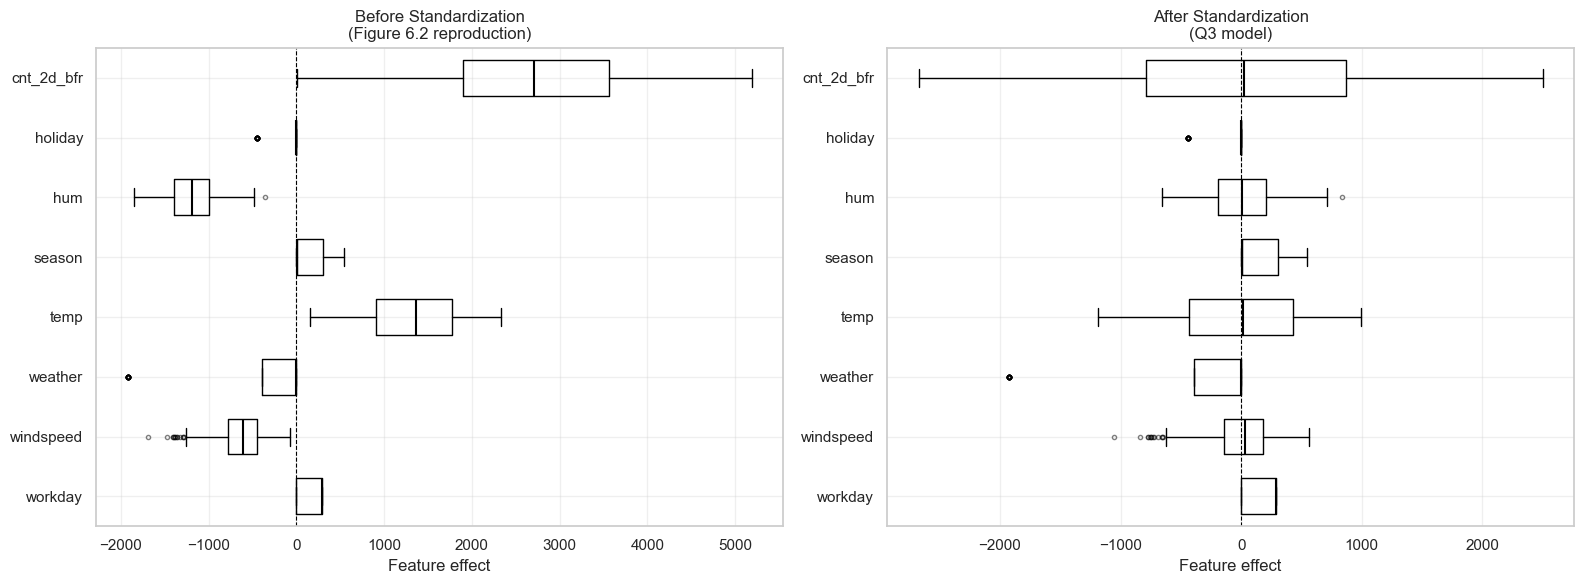

In [90]:
def effect_plot(effects, ax, title, instance_effects=None):
    """
    Reproduce Figure 6.2/6.3 style: horizontal boxplots of feature effects.
    Optionally overlay a specific instance's effects as red X markers (Figure 6.3).
    """
    feature_order = list(effects.columns)
    data_to_plot = [effects[f].values for f in feature_order]

    bp = ax.boxplot(data_to_plot, vert=False, labels=feature_order,
                    patch_artist=False, widths=0.6,
                    medianprops=dict(color="black", linewidth=1.5),
                    flierprops=dict(marker="o", markersize=3, alpha=0.5))

    ax.axvline(x=0, color="black", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Feature effect")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # Overlay instance effects as red X markers (for Figure 6.3)
    if instance_effects is not None:
        for i, feat in enumerate(feature_order):
            ax.plot(instance_effects[feat], i + 1, "rx", markersize=10, markeredgewidth=2.5)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

effect_plot(effects_unstd, axes[0], "Before Standardization\n(Figure 6.2 reproduction)")
effect_plot(effects_std, axes[1], "After Standardization\n(Q3 model)")

plt.tight_layout()
plt.show()

### Effect Plots: Discussion

**Model A (unstandardized) is actually more natural for effect plots.** Here's why:

The effects are in **bike count units** -- you can directly read "temperature contributes
roughly +500 to +2500 bikes depending on the day." This is intuitive and actionable.

In Model B (standardized), the numerical effects are in terms of standardized units, which
are harder to translate back to real-world meaning. The distributions shift and compress
because the feature values themselves have been rescaled.

**The key insight**: Weight plots and effect plots serve different purposes:
- **Weight plots** benefit from standardization (makes weights comparable)
- **Effect plots** benefit from raw units (makes effects interpretable in real terms)

Notice how `cnt_2d_bfr` dominates the effect plot despite having the smallest weight (0.6)
in Table 6.1. This is exactly why Molnar presents *both* visualizations -- they tell
complementary stories about the same model.

---
## Q8: Prediction Decomposition for Instance 6 (Figure 6.3)

> *"Effect plot for one linear model prediction for the bike data. The boxplots show overall
> effect distributions while the crosses mark the effects for the instance of interest."*
> -- Molnar, Ch. 6, Figure 6.3 caption

This is the payoff of linear regression's interpretability. For any single prediction, we
can decompose it exactly:

**prediction = intercept + effect_season + effect_holiday + effect_workday + effect_weather + effect_temp + effect_hum + effect_windspeed + effect_cnt_2d_bfr**

Figure 6.3 shows:
- The **boxplots**: distribution of each feature's effect across all 728 data points (same as Figure 6.2)
- The **red X markers**: where instance 6's effects fall within those distributions
- The **title**: predicted value, average prediction, and actual value

This lets us answer: "Why did the model predict 1238 bikes for this day? Because it was a
winter weekend (season effect near 0), with moderate temperature (below-average temp effect),
and low prior bike counts (cnt_2d_bfr effect well below the median)."

The book uses **instance index 6** (0-indexed from the processed dataset).

In [91]:
# Instance 6 (0-indexed) from the processed dataset
instance_idx = 6

# Show instance 6's raw feature values
print("Instance 6 feature values:")
display(X.iloc[[instance_idx]])
print(f"\nActual bike count: {y.iloc[instance_idx]}")

# Instance 6's effects from the unstandardized model (matches Figure 6.3 in the book)
inst_effects = effects_unstd.iloc[instance_idx]
print(f"\nInstance 6 effects (unstandardized model):")
for feat in plot_features:
    print(f"  {feat:>12s}: {inst_effects[feat]:+.1f}")

# Verify decomposition: intercept + sum(effects) = prediction
intercept_unstd = model_unstd["beta"][0]
predicted = intercept_unstd + inst_effects.sum()
avg_predicted = model_unstd["fitted"].mean()

print(f"\n  {'Intercept':>12s}: {intercept_unstd:+.1f}")
print(f"  {'SUM':>12s}: {predicted:.0f}")
print(f"\nPredicted value for instance 6: {predicted:.0f}")
print(f"Average predicted value:         {avg_predicted:.0f}")
print(f"Actual value:                    {y.iloc[instance_idx]}")

Instance 6 feature values:


,season,holiday,workday,weather,temp,hum,windspeed,cnt_2d_bfr
6,WINTER,N,N,GOOD,5.671653,43.4167,24.25065,1510.0



Actual bike count: 822

Instance 6 effects (unstandardized model):
       workday: +0.0
     windspeed: -1206.1
       weather: +0.0
          temp: +375.3
        season: +0.0
           hum: -825.9
       holiday: +0.0
    cnt_2d_bfr: +899.3

     Intercept: +2100.9
           SUM: 1343

Predicted value for instance 6: 1343
Average predicted value:         4520
Actual value:                    822


/var/folders/zm/14ysfl9x12983lr7y0jrsz1c0000gn/T/ipykernel_21424/1883757891.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, vert=False, labels=feature_order,


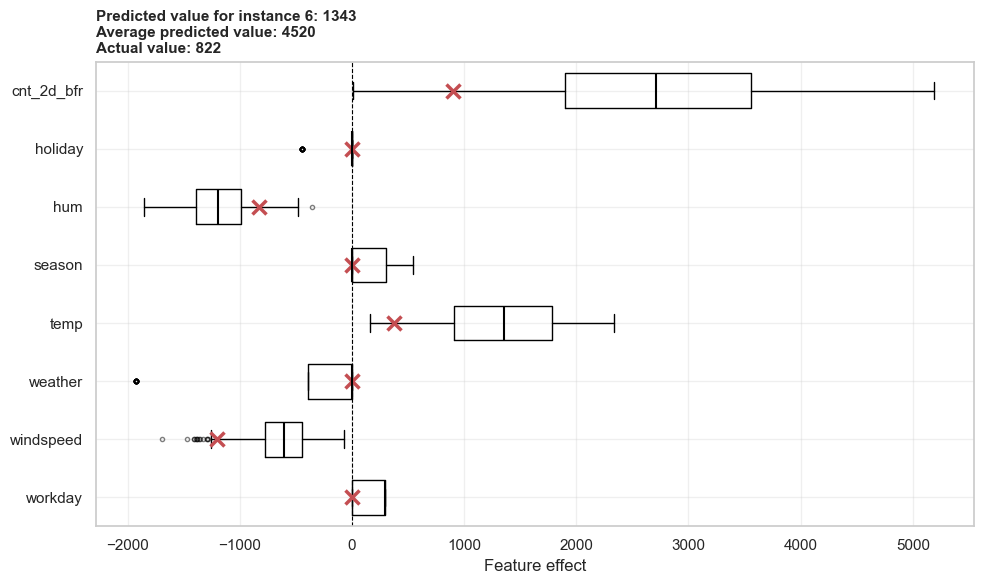

In [92]:
# ── Figure 6.3 Reproduction ──
# Effect plot with instance 6's effects overlaid as red X markers

fig, ax = plt.subplots(figsize=(10, 6))

# Get instance 6's specific effects
inst_effects_dict = effects_unstd.iloc[instance_idx].to_dict()

# Predicted values for the title
predicted_val = intercept_unstd + effects_unstd.iloc[instance_idx].sum()
actual_val = y.iloc[instance_idx]

# Draw the effect plot with the instance overlay
effect_plot(effects_unstd, ax,
            title="",  # we'll set a custom multi-line title below
            instance_effects=inst_effects_dict)

# Multi-line title matching Figure 6.3 style
ax.set_title(
    f"Predicted value for instance {instance_idx}: {predicted_val:.0f}\n"
    f"Average predicted value: {avg_predicted:.0f}\n"
    f"Actual value: {actual_val}",
    fontsize=11, loc="left", fontweight="bold"
)

plt.tight_layout()
plt.show()

### How the Prediction Decomposes

The red X markers above show exactly how the model arrives at its prediction for instance 6.
Each marker shows that feature's contribution *for this specific day*, positioned against
the background distribution of effects across all 728 days.

**Reading the plot**:
- A red X to the **right** of the boxplot center means this feature is pushing the prediction
  **higher** than it does on a typical day
- A red X to the **left** means this feature is pushing the prediction **lower**
- The **distance from zero** is the actual bike count contributed by that feature

This is the fundamental interpretability property of linear regression:

> Every prediction can be **additively decomposed** into the intercept plus one contribution
> per feature. There are no interactions, no hidden non-linearities -- what you see is
> exactly what the model computed.

This transparency is why linear regression remains valuable even when more accurate models
exist. You trade predictive power for the ability to fully explain every prediction.